# 08 — Exploratory Data Analysis (EDA): Titanic Dataset

**Objective:** Explore the cleaned Titanic dataset, answer 10 meaningful questions, and create visualizations that communicate useful findings.

**How to use**
1. Run this notebook after completing `07_Data_Cleaning.ipynb`.
2. The notebook first looks for `data/titanic_cleaned.csv` (or `../data/titanic_cleaned.csv`), then falls back to the public Seaborn Titanic dataset.
3. Run every cell from top to bottom. Interpret the actual outputs—do not copy assumptions as findings.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

candidate_paths = [
    Path("data/titanic_cleaned.csv"),
    Path("../data/titanic_cleaned.csv"),
]
data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path:
    df = pd.read_csv(data_path)
    print(f"Loaded cleaned dataset from: {data_path}")
else:
    print("Cleaned CSV not found. Loading Seaborn's public Titanic dataset instead.")
    df = sns.load_dataset("titanic")

df.head()

Cleaned CSV not found. Loading Seaborn's public Titanic dataset instead.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types and non-null counts:")
df.info()
print("\nNumerical summary:")
display(df.describe(include="number").T)
print("\nCategorical summary:")
display(df.describe(include="object").T)

Dataset shape: (891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null 

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



Categorical summary:


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
who,891,3,man,537
embark_town,889,3,Southampton,644
alive,891,2,no,549


## Initial Data Quality Check

In [6]:
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))
print("Exact duplicate rows:", df.duplicated().sum())

,missing_values
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


Exact duplicate rows: 107


## 10 EDA Questions

Each section displays a result and/or chart. Use the outputs to write evidence-based observations in the final findings section.

### Q1. What is the overall survival rate?

Overall survival rate: 38.38%


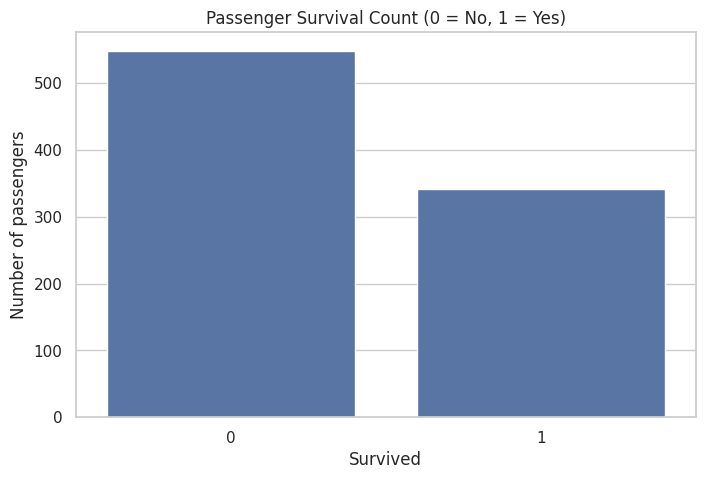

In [7]:
if "survived" in df.columns:
    survival_rate = df["survived"].mean() * 100
    print(f"Overall survival rate: {survival_rate:.2f}%")
    sns.countplot(data=df, x="survived")
    plt.title("Passenger Survival Count (0 = No, 1 = Yes)")
    plt.xlabel("Survived")
    plt.ylabel("Number of passengers")
    plt.show()
else:
    print("Column 'survived' is unavailable.")

### Q2. How did survival differ by passenger sex?

,survival_rate_%
sex,
female,74.20
male,18.89


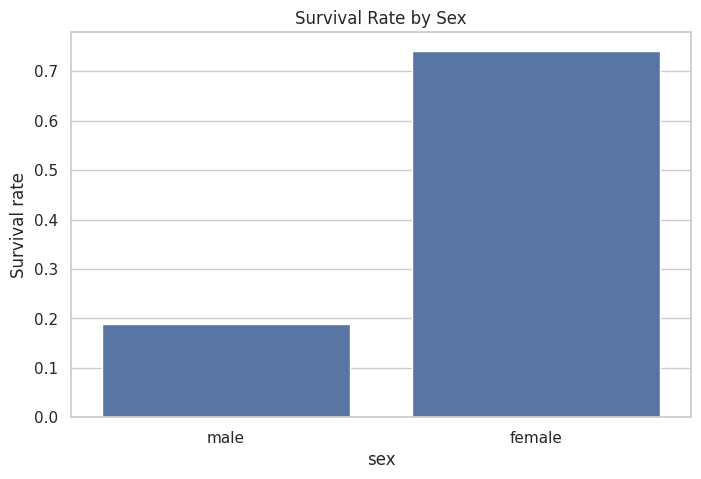

In [8]:
if {"sex", "survived"}.issubset(df.columns):
    display((df.groupby("sex", observed=False)["survived"].mean()*100).rename("survival_rate_%").round(2))
    sns.barplot(data=df, x="sex", y="survived", errorbar=None)
    plt.title("Survival Rate by Sex")
    plt.ylabel("Survival rate")
    plt.show()

### Q3. How did survival vary across passenger classes?

,survival_rate_%
pclass,
1,62.96
2,47.28
3,24.24


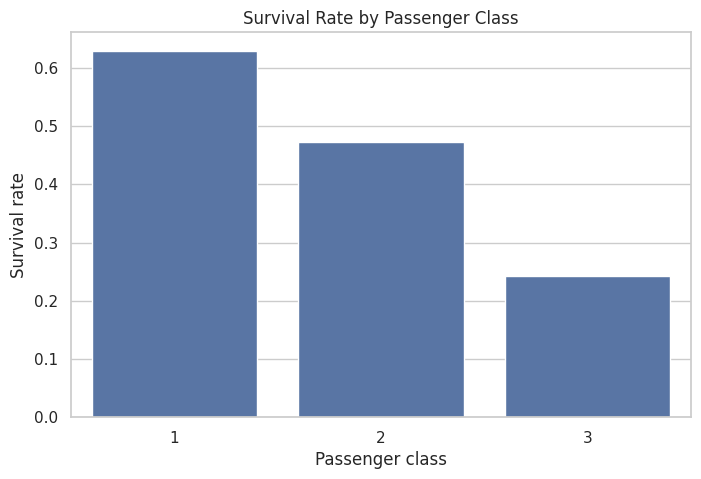

In [9]:
if {"pclass", "survived"}.issubset(df.columns):
    display((df.groupby("pclass", observed=False)["survived"].mean()*100).rename("survival_rate_%").round(2))
    sns.barplot(data=df, x="pclass", y="survived", errorbar=None)
    plt.title("Survival Rate by Passenger Class")
    plt.xlabel("Passenger class")
    plt.ylabel("Survival rate")
    plt.show()

### Q4. What was the age distribution of passengers?

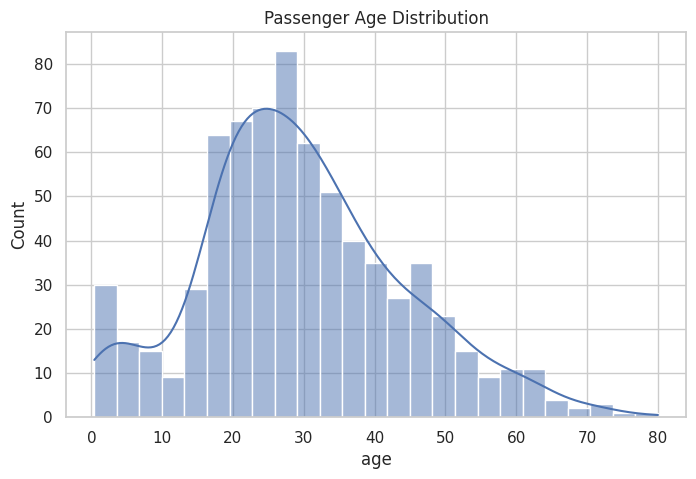

count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: age, dtype: float64


In [10]:
if "age" in df.columns:
    sns.histplot(data=df, x="age", bins=25, kde=True)
    plt.title("Passenger Age Distribution")
    plt.show()
    print(df["age"].describe().round(2))

### Q5. Did survival rates differ across age groups?

,survival_rate_%
age_group,
Child (0–12),57.97
Teen (13–18),42.86
Adult (19–35),38.27
Middle age (36–60),40.00
Senior (60+),22.73


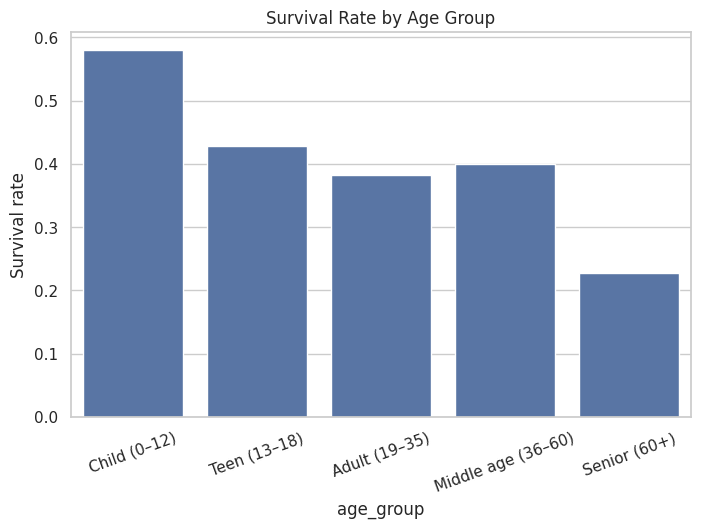

In [11]:
if {"age", "survived"}.issubset(df.columns):
    age_df = df.dropna(subset=["age", "survived"]).copy()
    age_df["age_group"] = pd.cut(age_df["age"], bins=[0, 12, 18, 35, 60, 100],
                                 labels=["Child (0–12)", "Teen (13–18)", "Adult (19–35)",
                                         "Middle age (36–60)", "Senior (60+)"], include_lowest=True)
    display((age_df.groupby("age_group", observed=False)["survived"].mean()*100).rename("survival_rate_%").round(2))
    sns.barplot(data=age_df, x="age_group", y="survived", errorbar=None)
    plt.title("Survival Rate by Age Group")
    plt.xticks(rotation=20)
    plt.ylabel("Survival rate")
    plt.show()

### Q6. How did ticket fare vary by passenger class?

,count,mean,median
pclass,,,
1,216,84.15,60.29
2,184,20.66,14.25
3,491,13.68,8.05


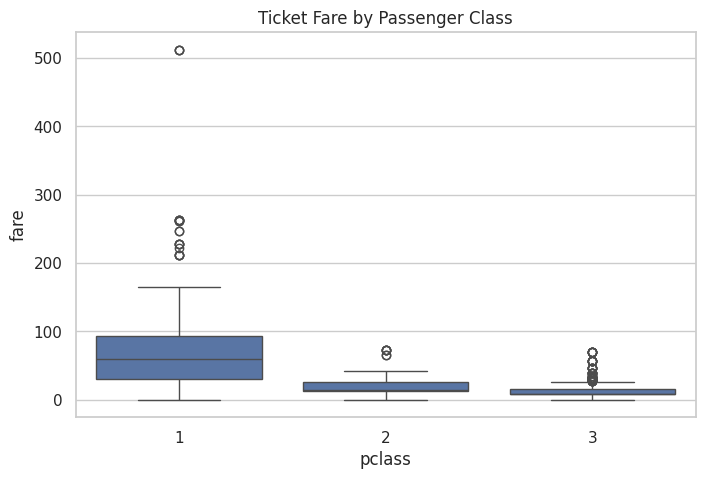

In [12]:
if {"fare", "pclass"}.issubset(df.columns):
    display(df.groupby("pclass", observed=False)["fare"].agg(["count", "mean", "median"]).round(2))
    sns.boxplot(data=df, x="pclass", y="fare")
    plt.title("Ticket Fare by Passenger Class")
    plt.show()

### Q7. Was survival associated with the port of embarkation?

,survival_rate_%
embarked,
C,55.36
Q,38.96
S,33.70


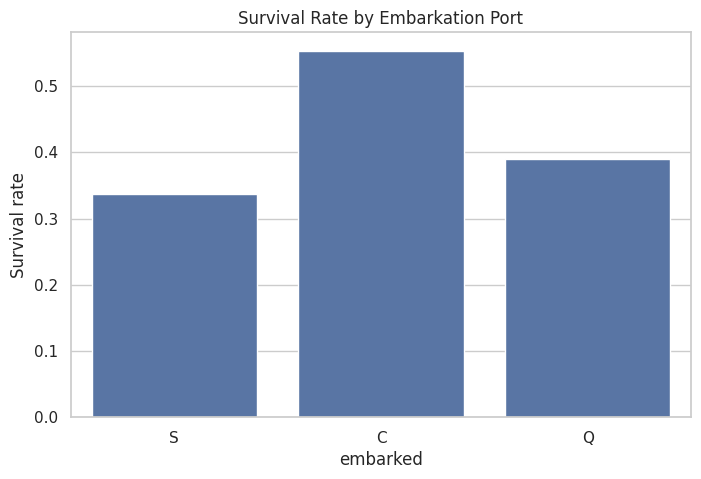

In [13]:
if {"embarked", "survived"}.issubset(df.columns):
    display((df.groupby("embarked", observed=False)["survived"].mean()*100).rename("survival_rate_%").round(2))
    sns.barplot(data=df, x="embarked", y="survived", errorbar=None)
    plt.title("Survival Rate by Embarkation Port")
    plt.ylabel("Survival rate")
    plt.show()

### Q8. Did traveling with family relate to survival?

,survival_rate_%
family_group,
Alone,30.35
Large family (5+),16.13
Small family (2–4),57.88


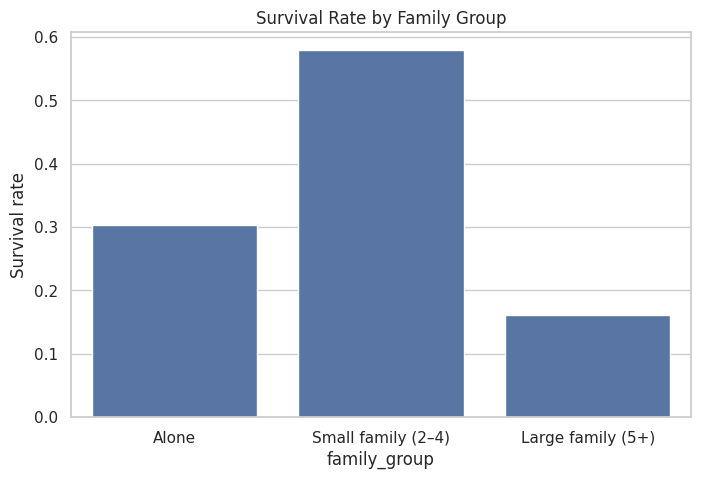

In [14]:
if {"sibsp", "parch", "survived"}.issubset(df.columns):
    family_df = df.copy()
    family_df["family_size"] = family_df["sibsp"].fillna(0) + family_df["parch"].fillna(0) + 1
    family_df["family_group"] = np.select(
        [family_df["family_size"].eq(1), family_df["family_size"].between(2, 4), family_df["family_size"].ge(5)],
        ["Alone", "Small family (2–4)", "Large family (5+)"], default="Unknown")
    display((family_df.groupby("family_group")["survived"].mean()*100).rename("survival_rate_%").round(2))
    sns.barplot(data=family_df, x="family_group", y="survived", errorbar=None,
                order=["Alone", "Small family (2–4)", "Large family (5+)"])
    plt.title("Survival Rate by Family Group")
    plt.ylabel("Survival rate")
    plt.show()

### Q9. Which passenger classes had the highest passenger counts?

,passenger_count
pclass,
1,216
2,184
3,491


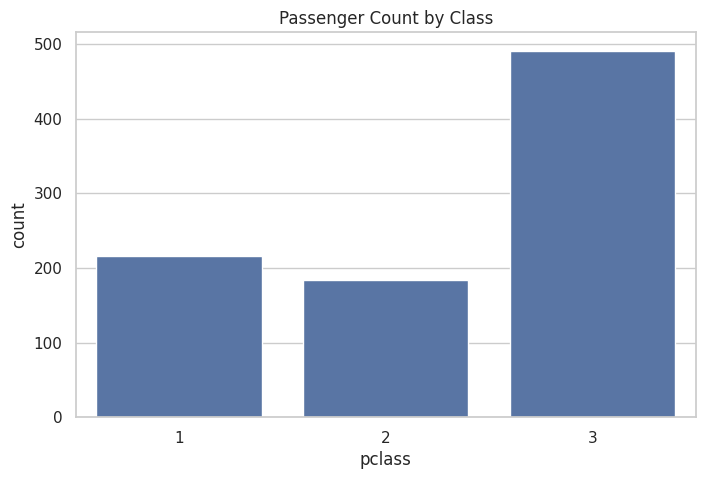

In [15]:
if "pclass" in df.columns:
    counts = df["pclass"].value_counts().sort_index()
    display(counts.rename("passenger_count").to_frame())
    sns.countplot(data=df, x="pclass", order=sorted(df["pclass"].dropna().unique()))
    plt.title("Passenger Count by Class")
    plt.show()

### Q10. How do sex and passenger class jointly relate to survival?

passenger_class,1,2,3
sex,,,
female,96.81,92.11,50.00
male,36.89,15.74,13.54


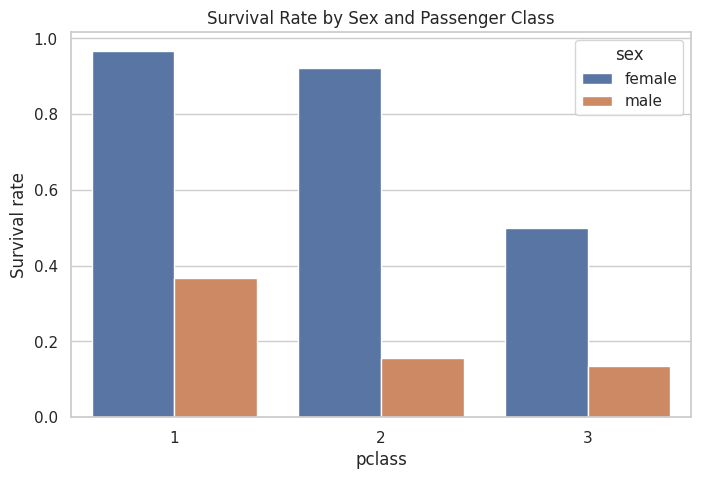

In [16]:
if {"sex", "pclass", "survived"}.issubset(df.columns):
    pivot = df.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean") * 100
    display(pivot.round(2).rename_axis(index="sex", columns="passenger_class"))
    sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
    plt.title("Survival Rate by Sex and Passenger Class")
    plt.ylabel("Survival rate")
    plt.show()

## Additional Visualization: Correlation Heatmap

Correlation describes linear association between numeric variables; it does not establish causation.

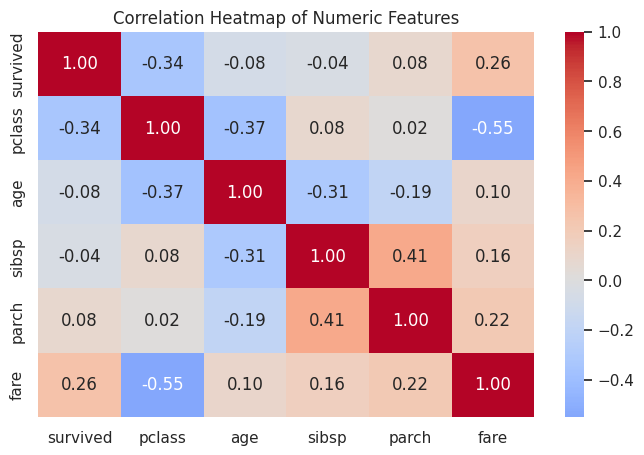

In [17]:
numeric_df = df.select_dtypes(include="number")
if numeric_df.shape[1] >= 2:
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
    plt.title("Correlation Heatmap of Numeric Features")
    plt.show()
else:
    print("Not enough numeric columns for a correlation heatmap.")

## Findings & Interpretation (Complete After Running)

Write 5–8 concise observations using the actual values and charts above.

1. Overall survival rate:
2. Survival differences by sex:
3. Survival differences by passenger class:
4. Age distribution and age-group pattern:
5. Fare differences by class:
6. Embarkation-port pattern:
7. Family-size pattern:
8. Any additional insight or limitation:

**Important:** These are descriptive associations in this dataset, not proof that a factor caused survival. Mention missing data or small group sizes where relevant.

## Save an EDA Summary Table (Optional)

This creates a small CSV of selected group survival rates when the required columns are present.

In [18]:
summary_parts = []
if {"sex", "survived"}.issubset(df.columns):
    t = (df.groupby("sex", observed=False)["survived"].mean()*100).rename("survival_rate_percent").reset_index()
    t["analysis"] = "survival_by_sex"
    t = t.rename(columns={"sex": "group"})
    summary_parts.append(t[["analysis", "group", "survival_rate_percent"]])

if {"pclass", "survived"}.issubset(df.columns):
    t = (df.groupby("pclass", observed=False)["survived"].mean()*100).rename("survival_rate_percent").reset_index()
    t["analysis"] = "survival_by_class"
    t = t.rename(columns={"pclass": "group"})
    summary_parts.append(t[["analysis", "group", "survival_rate_percent"]])

if summary_parts:
    summary = pd.concat(summary_parts, ignore_index=True)
    output_dir = Path("outputs")
    output_dir.mkdir(exist_ok=True)
    summary.to_csv(output_dir / "eda_summary.csv", index=False)
    print("Saved:", output_dir / "eda_summary.csv")
    display(summary.round(2))
else:
    print("Required columns not available; summary was not created.")

Saved: outputs/eda_summary.csv


,analysis,group,survival_rate_percent
0,survival_by_sex,female,74.20
1,survival_by_sex,male,18.89
2,survival_by_class,1,62.96
3,survival_by_class,2,47.28
4,survival_by_class,3,24.24
